## Library + data setup

In [ ]:
%matplotlib inline
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import numpy as np
from collections import Counter
import re
from wordcloud import WordCloud

In [ ]:
ACCENT_T        = "#5B8DB8"   # blue   — transcripts
ACCENT_C        = "#E07B54"   # orange — comments

DOMAINS = [
    "careers", "creativity", "education", "relationships", "safety",
    "politics", "health", "spirituality", "wellness", "finance"
]

# Used an LLM to generate these stop words:
STOP_WORDS = {
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you",
    "your", "yours", "yourself", "yourselves", "he", "him", "his",
    "himself", "she", "her", "hers", "herself", "it", "its", "itself",
    "they", "them", "their", "theirs", "themselves", "what", "which",
    "who", "whom", "this", "that", "these", "those", "am", "is", "are",
    "was", "were", "be", "been", "being", "have", "has", "had", "having",
    "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if",
    "or", "because", "as", "until", "while", "of", "at", "by", "for",
    "with", "about", "against", "between", "into", "through", "during",
    "before", "after", "above", "below", "to", "from", "up", "down",
    "in", "out", "on", "off", "over", "under", "again", "further",
    "then", "once", "here", "there", "when", "where", "why", "how",
    "all", "both", "each", "few", "more", "most", "other", "some",
    "such", "no", "nor", "not", "only", "own", "same", "so", "than",
    "too", "very", "can", "will", "just", "should", "now", "any",
    "also", "well", "back", "even", "still", "way", "every", "never",
    "re", "ve", "ll", "isn", "aren", "wasn", "weren", "hasn", "hadn",
    "doesn", "don", "didn", "won", "wouldn", "couldn", "shouldn",
    "ai", "a.i", "artificial", "intelligence", "like", "think", "know",
    "really", "going", "want", "make", "use", "using", "used",
    "get", "got", "one", "would", "could", "right", "yeah", "okay",
    "thing", "things", "people", "much", "many", "lot", "go", "say",
    "said", "see", "time", "mean", "actually", "something", "everything",
    "anything", "need", "take", "look", "come", "new", "good", "great",
    "already", "around", "another", "always", "maybe", "might", "though",
    "across", "without", "within", "yes", "let", "put", "try", "help",
    "tell", "talk", "feel", "feels", "felt", "give", "gave", "given",
    "keep", "kept", "start", "started", "kind", "sort", "bit", "little",
    "big", "long", "real", "sure", "absolutely", "definitely", "probably",
    "basically",
}


In [ ]:
_cwd_data = pathlib.Path.cwd() / "data"
_abs_data = pathlib.Path("/Users/karinakhan/Desktop/CDMS/DSCI 510/final project/project/data")
DATA_DIR = _cwd_data if _cwd_data.exists() else _abs_data
print(f"Data directory: {DATA_DIR}")

df_t = pd.read_csv(DATA_DIR / "filtered_transcripts.csv")
df_c = pd.read_csv(DATA_DIR / "filtered_comments.csv")

# Standardise text column name
df_t = df_t.rename(columns={"sentence": "text"})
df_c = df_c.rename(columns={"comment_text": "text"})

# Extract year
df_t["year"] = df_t["publish_date"].astype(str).str[:4].astype(int)
df_c["year"] = df_c["publish_date"].astype(str).str[:4].astype(int)

print(f"Transcripts: {len(df_t):,} rows  |  Comments: {len(df_c):,} rows")


Data directory: /Users/karinakhan/Desktop/CDMS/DSCI 510/final project/project/data
Transcripts: 7,813 rows  |  Comments: 922 rows


## AI-Generated code for the below sections

## VADER Distribution

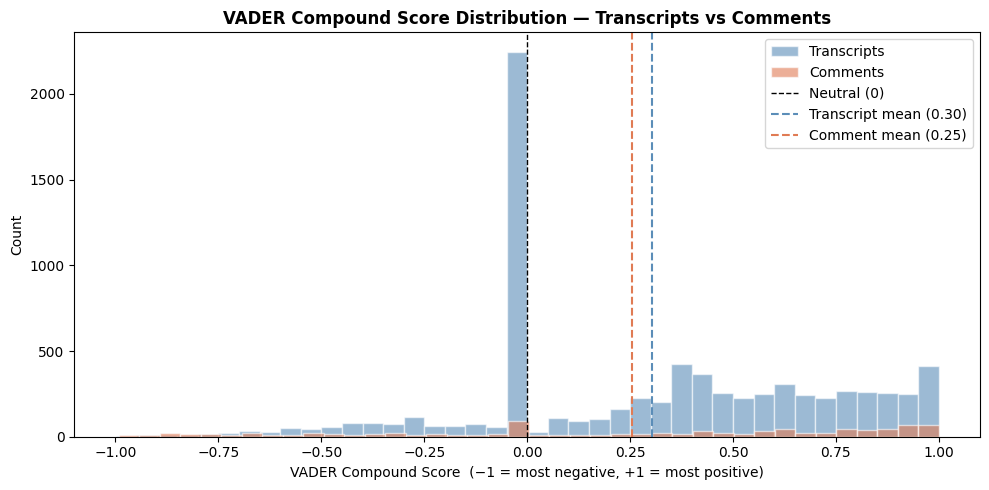

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_t["vader_score"], bins=40, color=ACCENT_T, alpha=0.6,
        label="Transcripts", edgecolor="white")
ax.hist(df_c["vader_score"], bins=40, color=ACCENT_C, alpha=0.6,
        label="Comments", edgecolor="white")

ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Neutral (0)")
ax.axvline(df_t["vader_score"].mean(), color=ACCENT_T, linewidth=1.5, linestyle="--",
           label=f"Transcript mean ({df_t['vader_score'].mean():.2f})")
ax.axvline(df_c["vader_score"].mean(), color=ACCENT_C, linewidth=1.5, linestyle="--",
           label=f"Comment mean ({df_c['vader_score'].mean():.2f})")

ax.set_title("VADER Compound Score Distribution — Transcripts vs Comments", fontweight="bold")
ax.set_xlabel("VADER Compound Score  (−1 = most negative, +1 = most positive)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


## Domain Share per Year (Stacked Bar)

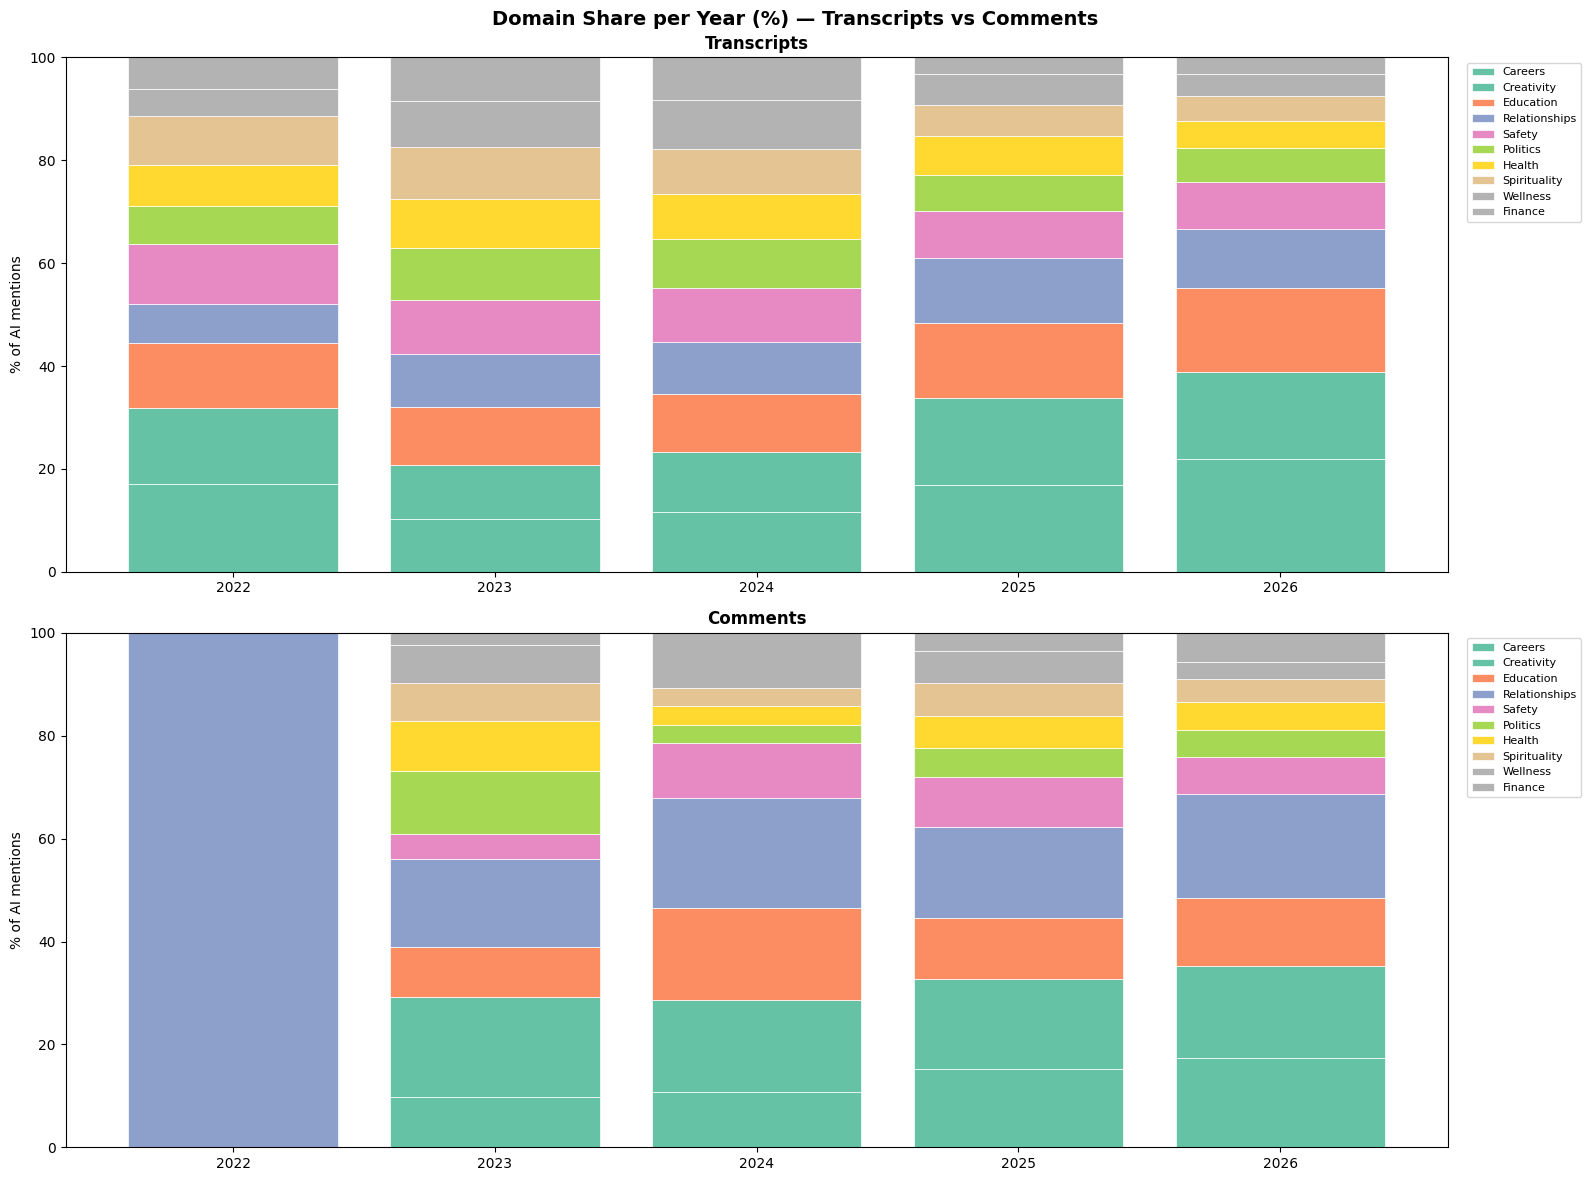

In [ ]:
def get_domain_year_counts(df, normalize=True):
    rows = []
    for domain in DOMAINS:
        mask = df["categories"].astype(str).str.contains(domain, na=False)
        for year, count in df[mask].groupby("year").size().items():
            rows.append({"year": year, "domain": domain, "count": count})
    pivot = pd.DataFrame(rows).pivot(index="year", columns="domain", values="count").fillna(0)
    if normalize:
        pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100
    return pivot

pivot_t = get_domain_year_counts(df_t)
pivot_c = get_domain_year_counts(df_c)
years = sorted(set(pivot_t.index) | set(pivot_c.index))
colors = cm.Set2(np.linspace(0, 1, len(DOMAINS)))

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=False)
fig.suptitle("Domain Share per Year (%) — Transcripts vs Comments",
             fontsize=14, fontweight="bold")

for ax, (pivot, label) in zip(axes, [(pivot_t, "Transcripts"), (pivot_c, "Comments")]):
    bottom = np.zeros(len(years))
    for i, domain in enumerate(DOMAINS):
        vals = [pivot.loc[y, domain] if y in pivot.index else 0 for y in years]
        ax.bar([str(y) for y in years], vals, bottom=bottom,
               label=domain.capitalize(), color=colors[i], edgecolor="white", linewidth=0.5)
        bottom += np.array(vals)
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("% of AI mentions")
    ax.set_ylim(0, 100)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


## Combined Data Frequency per Year (All Domains)

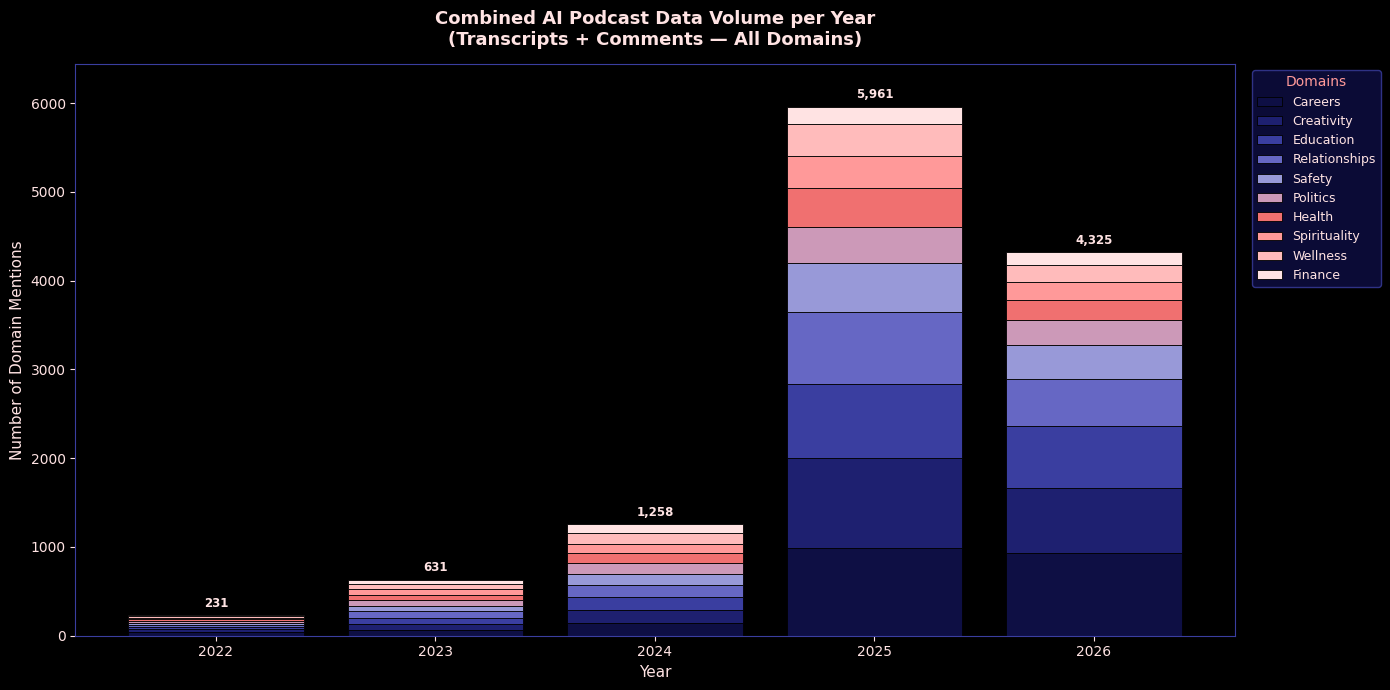

In [ ]:
# ── Colour palette: shades spanning #0e0f44 → mid-lavender → #ff9999 → #ffe3e3 ──
PALETTE_10 = [
    "#0e0f44",  # dark navy
    "#1e2070",  # navy
    "#3a3ea0",  # medium blue
    "#6667c4",  # lavender-blue
    "#9899d8",  # soft lavender
    "#cc99b8",  # muted rose
    "#f07070",  # salmon-pink
    "#ff9999",  # pink
    "#ffbbbb",  # light pink
    "#ffe3e3",  # very light pink
]

# ── Combine both sources ──────────────────────────────────────────────────────
df_t_tagged = df_t.copy(); df_t_tagged["source"] = "transcript"
df_c_tagged = df_c.copy(); df_c_tagged["source"] = "comment"
df_combined = pd.concat([df_t_tagged, df_c_tagged], ignore_index=True)

# ── Count per domain per year ─────────────────────────────────────────────────
rows = []
for domain in DOMAINS:
    mask = df_combined["categories"].astype(str).str.contains(domain, na=False)
    for year, count in df_combined[mask].groupby("year").size().items():
        rows.append({"year": year, "domain": domain, "count": count})

pivot_combined = (
    pd.DataFrame(rows)
    .pivot(index="year", columns="domain", values="count")
    .fillna(0)
)
years_all = sorted(pivot_combined.index)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

bottom = np.zeros(len(years_all))
x_labels = [str(y) for y in years_all]

for i, domain in enumerate(DOMAINS):
    vals = [pivot_combined.loc[y, domain] if y in pivot_combined.index else 0 for y in years_all]
    ax.bar(
        x_labels, vals, bottom=bottom,
        label=domain.capitalize(),
        color=PALETTE_10[i],
        edgecolor="#000000", linewidth=0.6,
    )
    bottom += np.array(vals)

# Annotate totals on top of each bar stack
totals = [pivot_combined.loc[y].sum() if y in pivot_combined.index else 0 for y in years_all]
for xi, total in enumerate(totals):
    ax.text(xi, total + max(totals) * 0.01, f"{int(total):,}",
            ha="center", va="bottom", color="#ffe3e3", fontsize=8.5, fontweight="bold")

ax.set_ylim(0, max(totals) * 1.08)

# ── Styling ───────────────────────────────────────────────────────────────────
ax.set_title(
    "Combined AI Podcast Data Volume per Year\n(Transcripts + Comments — All Domains)",
    fontweight="bold", color="#ffe3e3", fontsize=13, pad=14,
)
ax.set_xlabel("Year", color="#ffe3e3", fontsize=11)
ax.set_ylabel("Number of Domain Mentions", color="#ffe3e3", fontsize=11)
ax.tick_params(axis="both", colors="#ffe3e3")
for spine in ax.spines.values():
    spine.set_edgecolor("#3a3ea0")

legend = ax.legend(
    title="Domains",
    bbox_to_anchor=(1.01, 1), loc="upper left",
    fontsize=9, title_fontsize=10,
    facecolor="#0e0f44", edgecolor="#3a3ea0",
    labelcolor="#ffe3e3",
)
legend.get_title().set_color("#ff9999")

plt.tight_layout()
plt.show()


## Sentiment per Year (All Domains Combined)

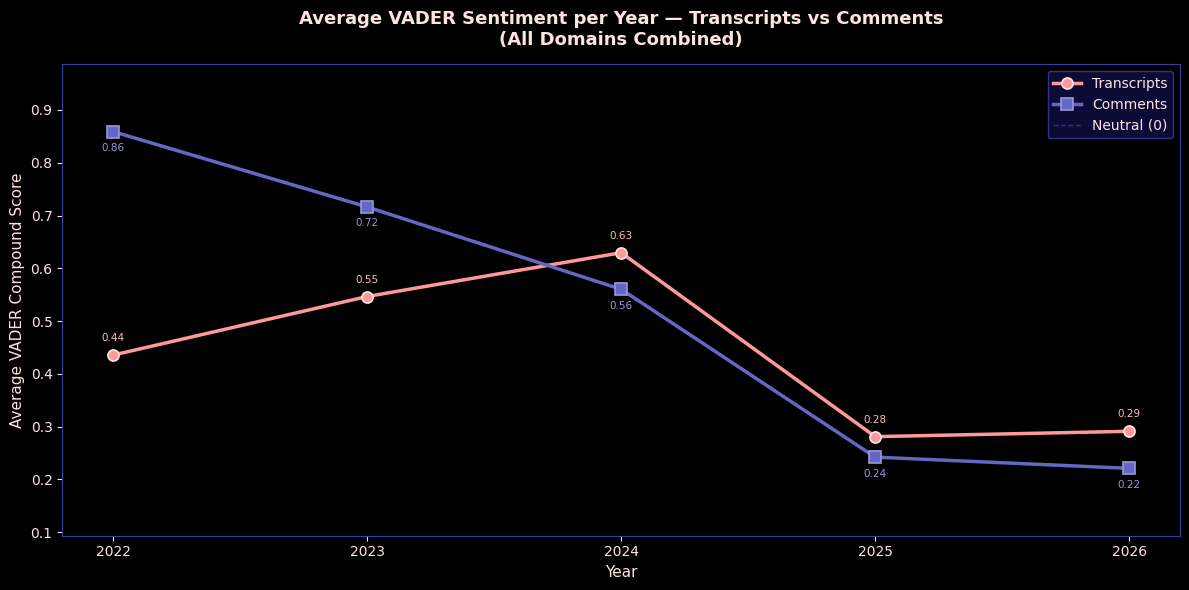

In [ ]:
sent_t_year = df_t.groupby("year")["vader_score"].mean()
sent_c_year = df_c.groupby("year")["vader_score"].mean()

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

# ── Lines ─────────────────────────────────────────────────────────────────────
ax.plot(
    sent_t_year.index, sent_t_year.values,
    "o-", color="#ff9999",
    linewidth=2.5, markersize=8,
    markerfacecolor="#ff9999", markeredgecolor="#ffe3e3", markeredgewidth=1.2,
    label="Transcripts",
)
ax.plot(
    sent_c_year.index, sent_c_year.values,
    "s-", color="#6667c4",
    linewidth=2.5, markersize=8,
    markerfacecolor="#6667c4", markeredgecolor="#9899d8", markeredgewidth=1.2,
    label="Comments",
)

# Neutral baseline
ax.axhline(0, color="#3a3ea0", linewidth=1, linestyle="--", alpha=0.75, label="Neutral (0)")

# ── Tight Y axis ──────────────────────────────────────────────────────────────
all_vals = pd.concat([sent_t_year, sent_c_year])
y_pad = (all_vals.max() - all_vals.min()) * 0.2
ax.set_ylim(all_vals.min() - y_pad, all_vals.max() + y_pad)

# ── Value labels on each data point ──────────────────────────────────────────
for year, val in sent_t_year.items():
    ax.annotate(f"{val:.2f}", (year, val),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=7.5, color="#ffbbbb")
for year, val in sent_c_year.items():
    ax.annotate(f"{val:.2f}", (year, val),
                textcoords="offset points", xytext=(0, -14),
                ha="center", fontsize=7.5, color="#9899d8")

# ── Styling ───────────────────────────────────────────────────────────────────
ax.set_title(
    "Average VADER Sentiment per Year — Transcripts vs Comments\n(All Domains Combined)",
    fontweight="bold", color="#ffe3e3", fontsize=13, pad=14,
)
ax.set_xlabel("Year", color="#ffe3e3", fontsize=11)
ax.set_ylabel("Average VADER Compound Score", color="#ffe3e3", fontsize=11)
ax.tick_params(axis="both", colors="#ffe3e3")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ax.spines.values():
    spine.set_edgecolor("#3a3ea0")

legend = ax.legend(
    facecolor="#0e0f44", edgecolor="#3a3ea0",
    labelcolor="#ffe3e3", fontsize=10,
)

plt.tight_layout()
plt.show()


## Average Sentiment per Domain per Year (Grouped Bar)

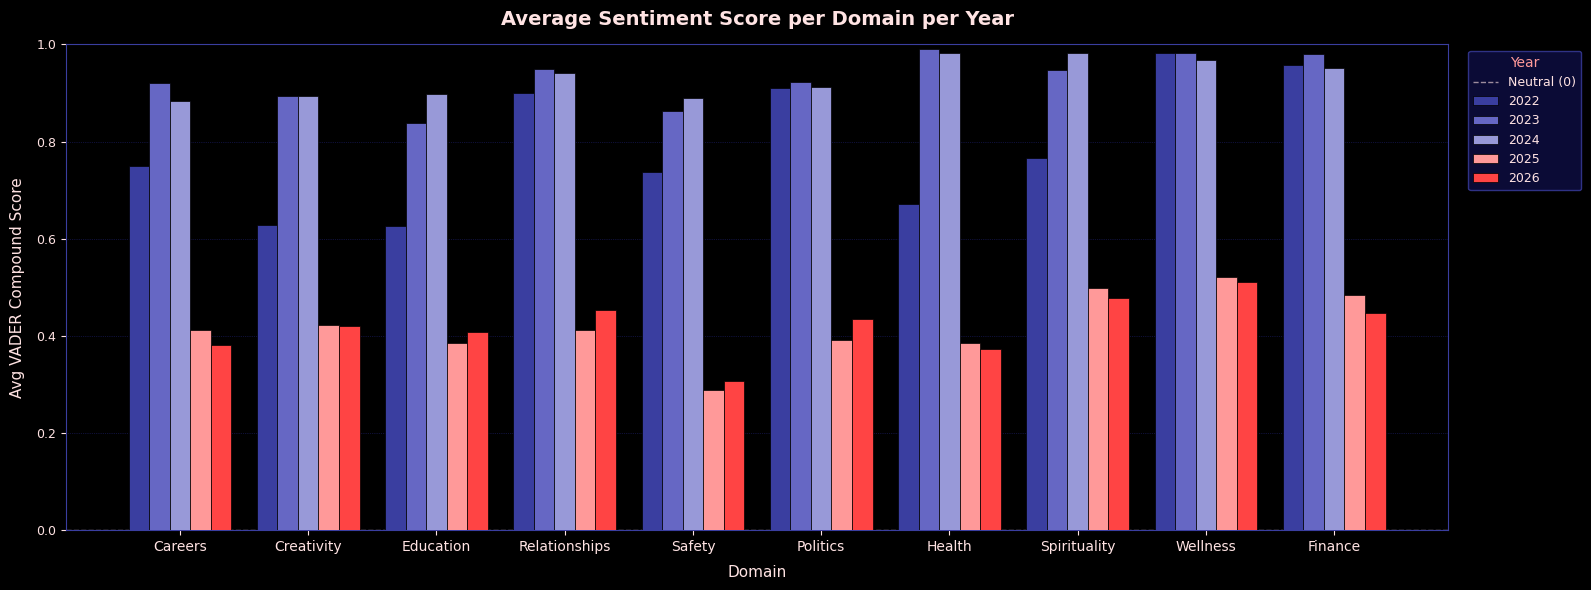

In [ ]:
# ── Build avg_sentiment DataFrame (transcripts + comments combined) ───────────
rows = []
for domain in DOMAINS:
    mask_t = df_t["categories"].astype(str).str.contains(domain, na=False)
    mask_c = df_c["categories"].astype(str).str.contains(domain, na=False)
    combined = pd.concat([
        df_t.loc[mask_t, ["year", "vader_score"]],
        df_c.loc[mask_c, ["year", "vader_score"]],
    ])
    for year, grp in combined.groupby("year"):
        rows.append({
            "domain": domain.capitalize(),
            "year": int(year),
            "avg_sentiment": grp["vader_score"].mean(),
        })

df_grouped = pd.DataFrame(rows)
years_g   = sorted(df_grouped["year"].unique())
domains_g = [d.capitalize() for d in DOMAINS]
n_years   = len(years_g)
n_domains = len(domains_g)

# ── Year colours: shades from deep navy → mid-blue → pink ────────────────────
year_colors = [
    "#3a3ea0",   # 2022 — mid-blue
    "#6667c4",   # 2023 — lavender-blue
    "#9899d8",   # 2024 — soft lavender
    "#ff9999",   # 2025 — pink
    "#ff4444",   # 2026 — vivid red
]
year_colors = year_colors[:n_years]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

bar_width = 0.8 / n_years
x = np.arange(n_domains)

for i, (year, color) in enumerate(zip(years_g, year_colors)):
    subset = df_grouped[df_grouped["year"] == year].set_index("domain")
    vals   = [subset.loc[d, "avg_sentiment"] if d in subset.index else np.nan
              for d in domains_g]
    offset = (i - n_years / 2 + 0.5) * bar_width
    ax.bar(
        x + offset, vals,
        width=bar_width,
        color=color,
        label=str(year),
        edgecolor="#000000",
        linewidth=0.5,
        zorder=3,
    )

# ── Neutral baseline ──────────────────────────────────────────────────────────
ax.axhline(0, color="#ffe3e3", linewidth=1, linestyle="--", alpha=0.6,
           label="Neutral (0)", zorder=2)

# ── Styling ───────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(domains_g, color="#ffe3e3", fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.tick_params(axis="y", colors="#ffe3e3", labelsize=9)
ax.tick_params(axis="x", colors="#ffe3e3")

ax.set_title(
    "Average Sentiment Score per Domain per Year",
    color="#ffe3e3", fontsize=14, fontweight="bold", pad=14,
)
ax.set_xlabel("Domain", color="#ffe3e3", fontsize=11, labelpad=8)
ax.set_ylabel("Avg VADER Compound Score", color="#ffe3e3", fontsize=11, labelpad=8)

for spine in ax.spines.values():
    spine.set_edgecolor("#3a3ea0")

ax.yaxis.grid(True, color="#1e2070", linewidth=0.5, linestyle=":", zorder=0)
ax.set_axisbelow(True)

legend = ax.legend(
    title="Year",
    bbox_to_anchor=(1.01, 1), loc="upper left",
    facecolor="#0e0f44", edgecolor="#3a3ea0",
    labelcolor="#ffe3e3", fontsize=9, title_fontsize=10,
)
legend.get_title().set_color("#ff9999")

plt.tight_layout()
plt.show()


## Top 10 Keywords per Domain

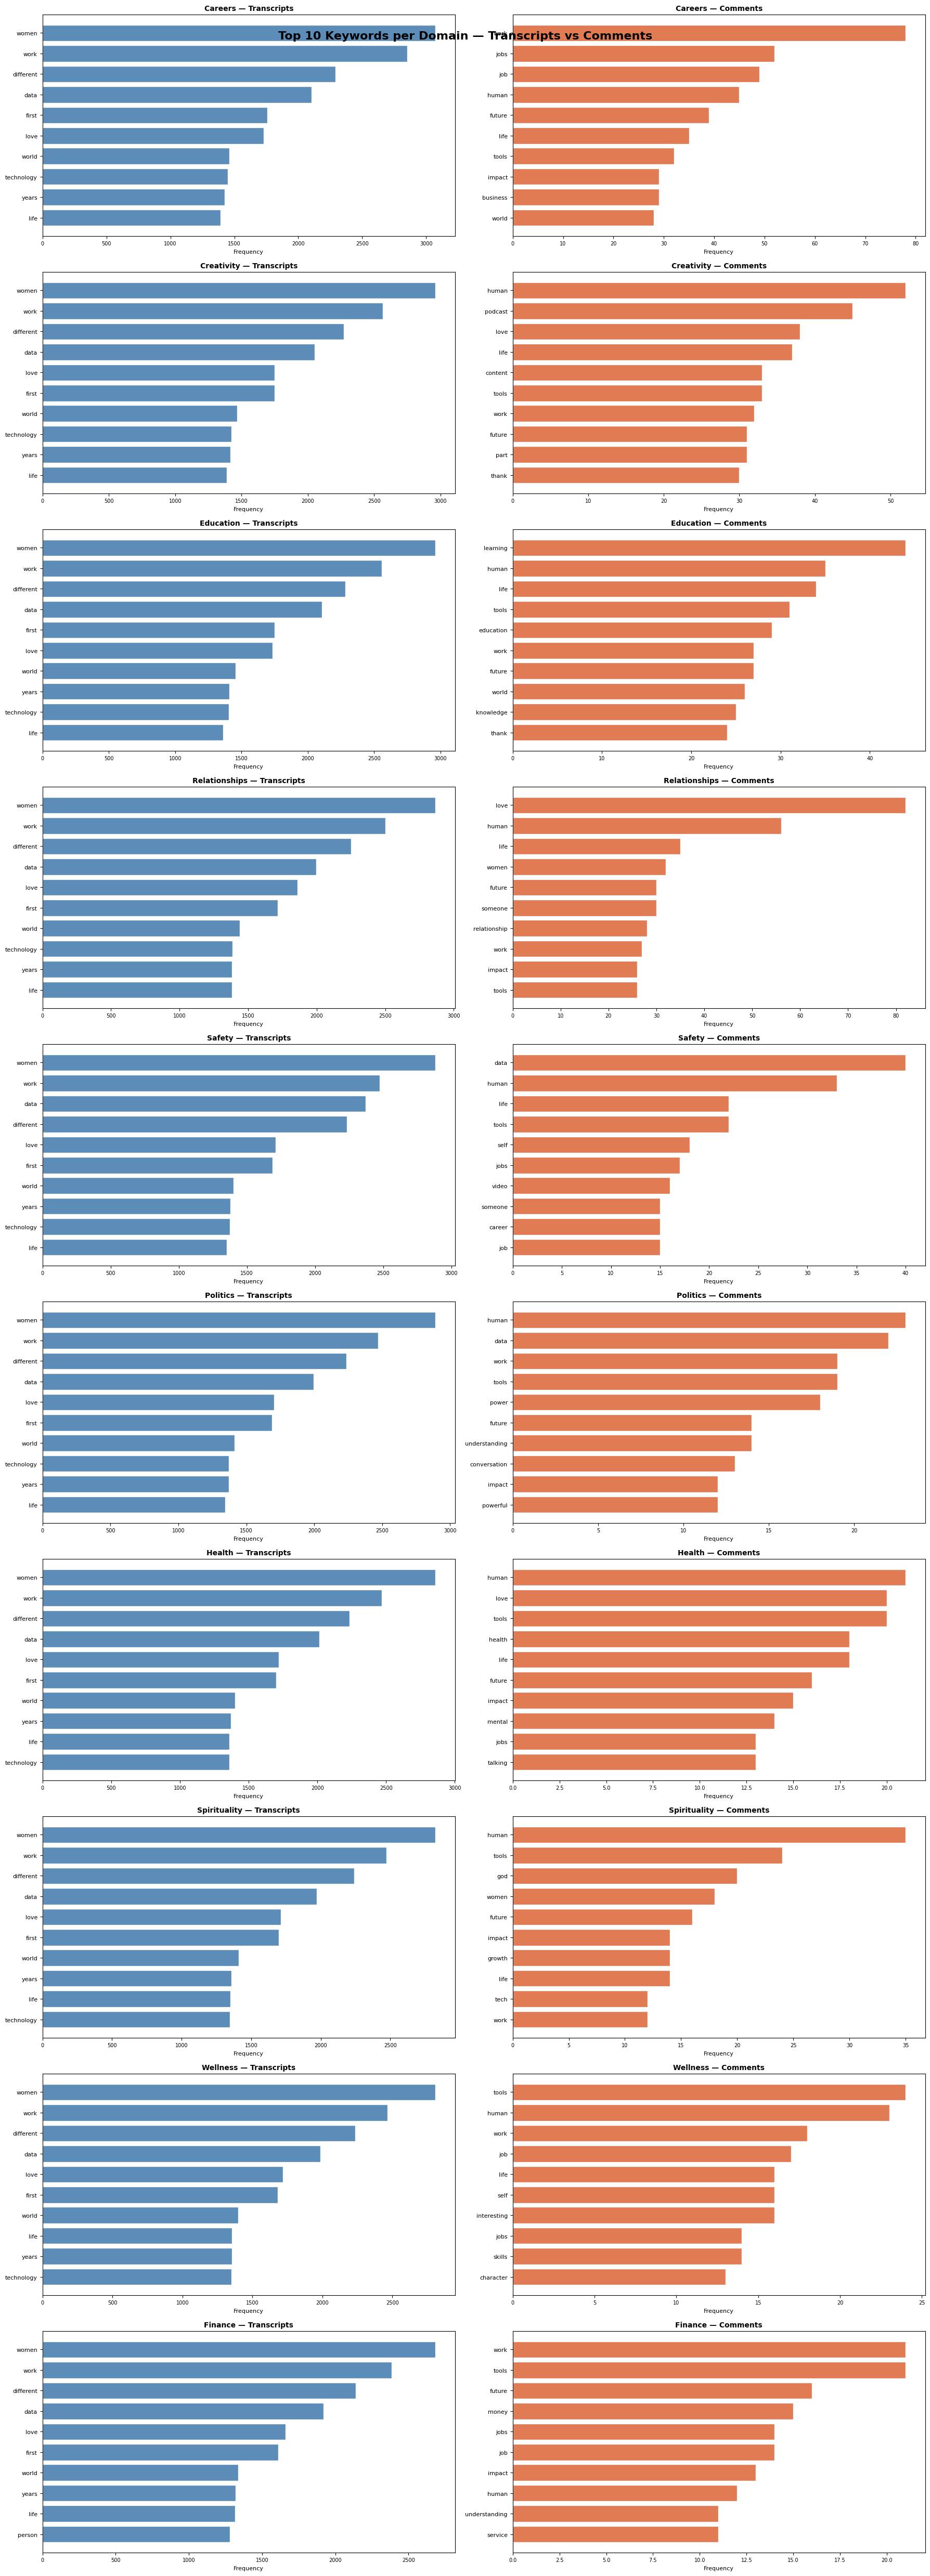

In [ ]:
def get_top_words(df, domain, top_n=10):
    mask = df["categories"].astype(str).str.contains(domain, na=False)
    all_words = []
    for text in df.loc[mask, "text"].astype(str):
        words = re.findall(r'\b[a-z]{3,}\b', text.lower())
        all_words.extend(w for w in words if w not in STOP_WORDS)
    return Counter(all_words).most_common(top_n)

fig, axes = plt.subplots(len(DOMAINS), 2, figsize=(18, 5 * len(DOMAINS)))
fig.suptitle("Top 10 Keywords per Domain — Transcripts vs Comments",
             fontsize=16, fontweight="bold")

for i, domain in enumerate(DOMAINS):
    for j, (df, label, color) in enumerate([
        (df_t, "Transcripts", ACCENT_T),
        (df_c, "Comments",    ACCENT_C)
    ]):
        ax = axes[i][j]
        top_words = get_top_words(df, domain, top_n=10)
        if not top_words:
            ax.set_title(f"{domain.capitalize()} — {label}", fontsize=10)
            ax.axis("off")
            continue
        words  = [w for w, _ in top_words]
        counts = [c for _, c in top_words]
        ax.barh(words[::-1], counts[::-1], color=color, edgecolor="white")
        ax.set_title(f"{domain.capitalize()} — {label}", fontsize=10, fontweight="bold")
        ax.tick_params(axis="y", labelsize=8)
        ax.tick_params(axis="x", labelsize=7)
        ax.set_xlabel("Frequency", fontsize=8)

plt.tight_layout()
plt.show()


## LDA Topic Clusters per Domain (Top 3 Topics)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

N_TOPICS    = 3
N_TOP_WORDS = 8

def get_domain_docs(df, domain):
    mask = df["categories"].astype(str).str.contains(domain, na=False)
    return df.loc[mask, "text"].astype(str).tolist()

def run_lda(docs, n_topics=N_TOPICS, n_top_words=N_TOP_WORDS):
    if len(docs) < n_topics:
        return None, None
    vec = CountVectorizer(
        stop_words=list(STOP_WORDS),
        token_pattern=r'\b[a-z]{3,}\b',
        min_df=2,
        max_df=0.95,
    )
    try:
        dtm = vec.fit_transform(docs)
    except ValueError:
        return None, None
    if dtm.shape[1] < n_top_words:
        return None, None
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        max_iter=20,
    )
    lda.fit(dtm)
    feature_names = vec.get_feature_names_out()
    topics = []
    for comp in lda.components_:
        top_idx = comp.argsort()[:-n_top_words - 1:-1]
        topics.append([feature_names[i] for i in top_idx])
    return topics, lda

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    len(DOMAINS), 2,
    figsize=(18, 4.5 * len(DOMAINS)),
    constrained_layout=True,
)
fig.suptitle(
    f"LDA Topic Clusters per Domain (top {N_TOPICS} topics, {N_TOP_WORDS} words each)\n"
    "Transcripts  |  Comments",
    fontsize=15, fontweight="bold",
)

TOPIC_COLORS = ["#5B8DB8", "#6db89e", "#a78dbf"]   # one colour per topic

for row, domain in enumerate(DOMAINS):
    for col, (df, label) in enumerate([(df_t, "Transcripts"), (df_c, "Comments")]):
        ax = axes[row][col]
        docs = get_domain_docs(df, domain)
        topics, _ = run_lda(docs)

        if topics is None:
            ax.text(0.5, 0.5, "Not enough data",
                    ha="center", va="center", transform=ax.transAxes, fontsize=10)
            ax.set_title(f"{domain.capitalize()} — {label}", fontsize=10, fontweight="bold")
            ax.axis("off")
            continue

        # One horizontal bar group per topic
        y_base   = 0
        y_ticks  = []
        y_labels = []
        gap      = 1.2   # spacing between topic blocks

        for t_idx, words in enumerate(topics):
            color  = TOPIC_COLORS[t_idx % len(TOPIC_COLORS)]
            y_pos  = [y_base + i for i in range(len(words))]
            # use rank as a proxy bar length (top word = longest bar)
            widths = [len(words) - i for i in range(len(words))]
            ax.barh(y_pos, widths, color=color, alpha=0.75, edgecolor="white")
            for y, word in zip(y_pos, words):
                ax.text(0.15, y, word, va="center", fontsize=7.5)
            # topic label on the left margin
            mid = y_base + len(words) / 2 - 0.5
            y_ticks.append(mid)
            y_labels.append(f"Topic {t_idx + 1}")
            y_base += len(words) + gap

        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_labels, fontsize=9, fontweight="bold")
        ax.set_title(f"{domain.capitalize()} — {label}  ({len(docs)} docs)",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel("Relative word rank", fontsize=8)
        ax.tick_params(axis="x", labelsize=7)
        ax.set_xlim(0, N_TOP_WORDS + 1)

plt.show()


## LDA Topic Clusters: Careers by Year (Transcripts & Comments)

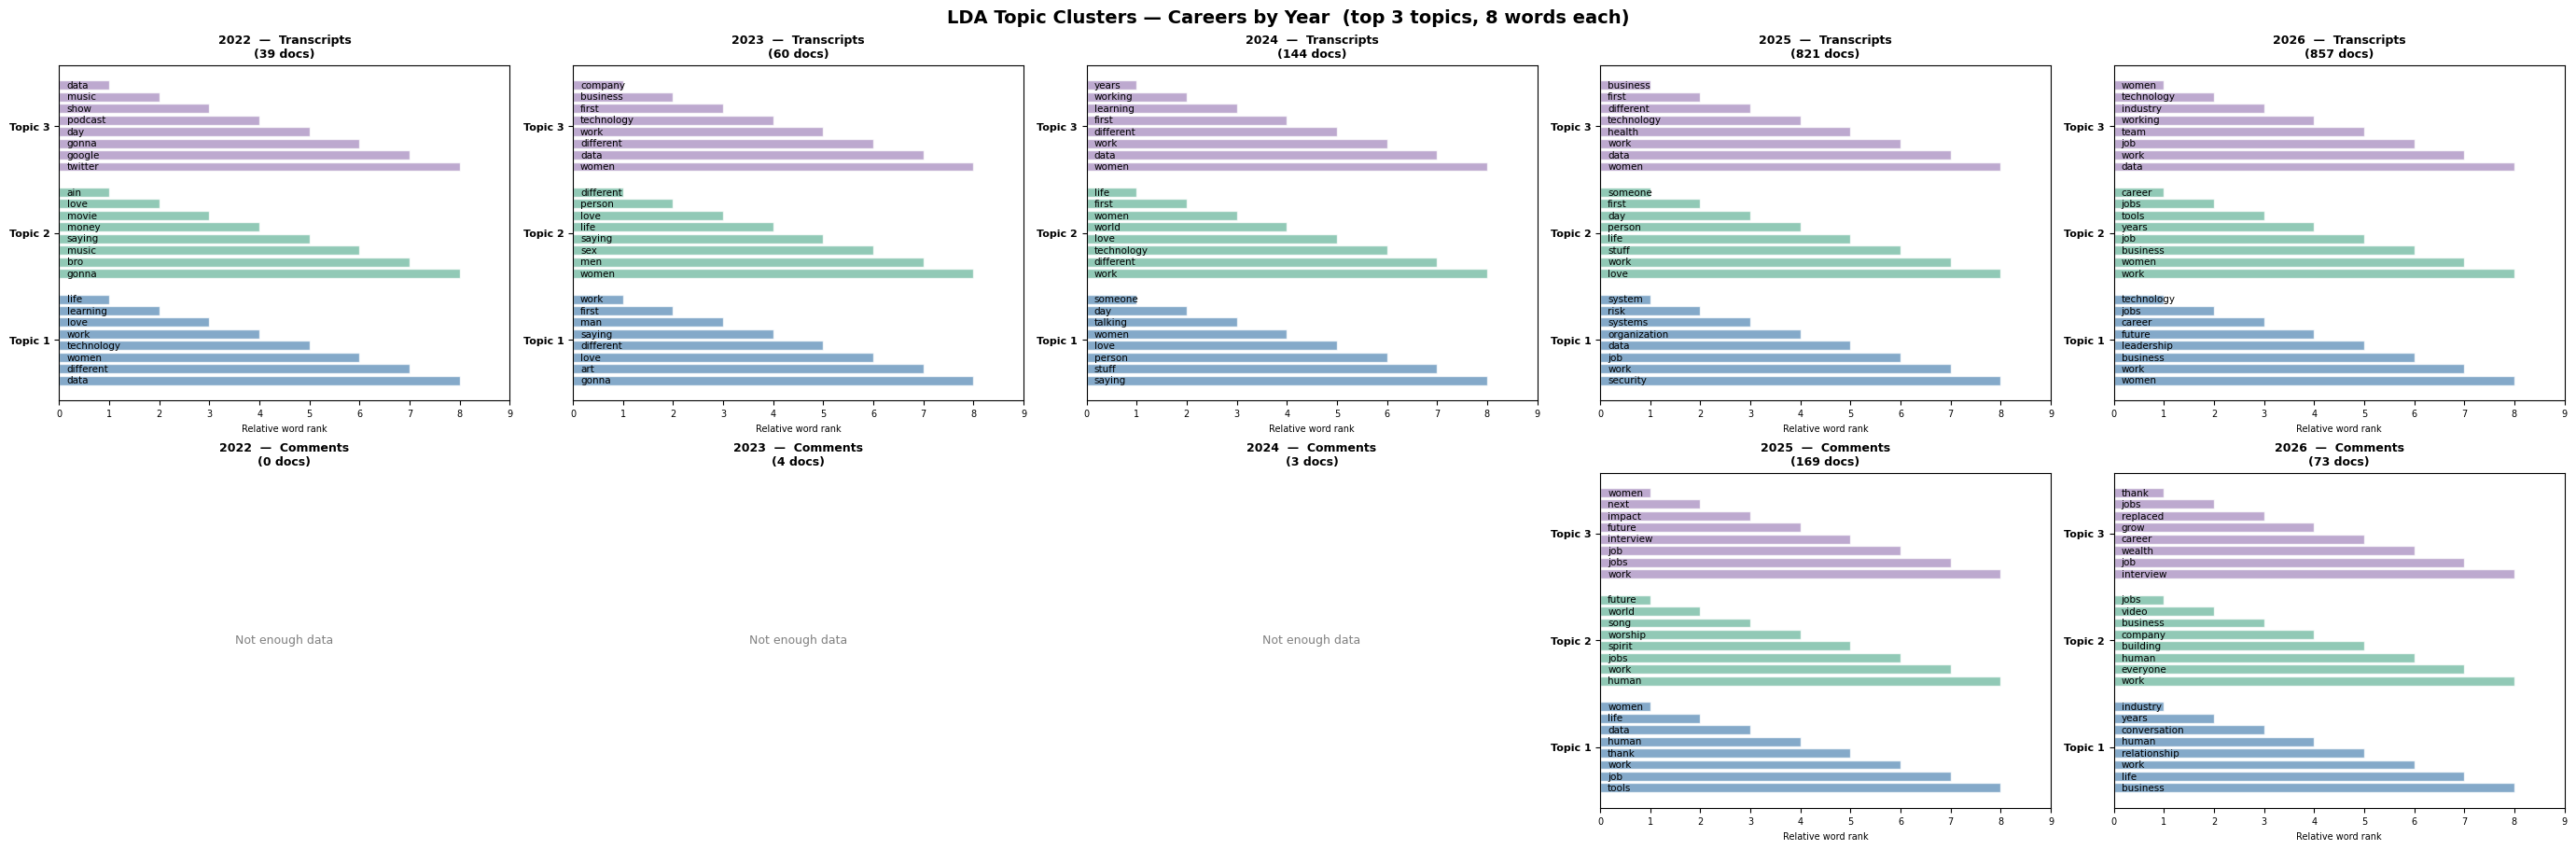

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

_N_TOPICS    = 3
_N_TOP_WORDS = 8
_DOMAIN      = "careers"

def _careers_docs_by_year(df):
    """Return {year: [doc, ...]} for the careers category."""
    mask = df["categories"].astype(str).str.contains(_DOMAIN, na=False)
    sub  = df.loc[mask, ["year", "text"]]
    out  = {}
    for year, grp in sub.groupby("year"):
        out[int(year)] = grp["text"].astype(str).tolist()
    return out

def _run_lda_year(docs):
    """Run LDA on a list of docs; return list of topic word lists or None."""
    if len(docs) < _N_TOPICS:
        return None
    vec = CountVectorizer(
        stop_words=list(STOP_WORDS),
        token_pattern=r'\b[a-z]{3,}\b',
        min_df=2,
        max_df=0.95,
    )
    try:
        dtm = vec.fit_transform(docs)
    except ValueError:
        return None
    if dtm.shape[1] < _N_TOP_WORDS:
        return None
    lda = LatentDirichletAllocation(
        n_components=_N_TOPICS,
        random_state=42,
        max_iter=30,
    )
    lda.fit(dtm)
    names  = vec.get_feature_names_out()
    topics = []
    for comp in lda.components_:
        idx = comp.argsort()[:-_N_TOP_WORDS - 1:-1]
        topics.append([names[i] for i in idx])
    return topics

# ── Gather data ───────────────────────────────────────────────────────────────
docs_t = _careers_docs_by_year(df_t)
docs_c = _careers_docs_by_year(df_c)
all_years = sorted(set(docs_t) | set(docs_c))

# ── Layout: one column per year, two rows (transcripts / comments) ─────────────
n_cols = len(all_years)
fig, axes = plt.subplots(
    2, n_cols,
    figsize=(5.5 * n_cols, 4.5 * 2),
    constrained_layout=True,
)
# Ensure axes is always 2-D
if n_cols == 1:
    axes = axes.reshape(2, 1)

fig.suptitle(
    f"LDA Topic Clusters — Careers by Year  "
    f"(top {_N_TOPICS} topics, {_N_TOP_WORDS} words each)",
    fontsize=14, fontweight="bold",
)

ROW_LABELS  = ["Transcripts", "Comments"]
TOPIC_COLORS = ["#5B8DB8", "#6db89e", "#a78dbf"]

for col, year in enumerate(all_years):
    for row, (docs_dict, label) in enumerate([(docs_t, "Transcripts"),
                                               (docs_c, "Comments")]):
        ax     = axes[row][col]
        docs   = docs_dict.get(year, [])
        topics = _run_lda_year(docs)

        ax.set_title(f"{year}  —  {label}\n({len(docs)} docs)",
                     fontsize=9, fontweight="bold")

        if topics is None:
            ax.text(0.5, 0.5, "Not enough data",
                    ha="center", va="center",
                    transform=ax.transAxes, fontsize=9, color="gray")
            ax.axis("off")
            continue

        y_base  = 0
        y_ticks = []
        y_lbls  = []
        gap     = 1.2

        for t_idx, words in enumerate(topics):
            color  = TOPIC_COLORS[t_idx % len(TOPIC_COLORS)]
            y_pos  = [y_base + i for i in range(len(words))]
            widths = [len(words) - i for i in range(len(words))]  # rank proxy
            ax.barh(y_pos, widths, color=color, alpha=0.75, edgecolor="white")
            for y, word in zip(y_pos, words):
                ax.text(0.15, y, word, va="center", fontsize=7.5)
            mid = y_base + len(words) / 2 - 0.5
            y_ticks.append(mid)
            y_lbls.append(f"Topic {t_idx + 1}")
            y_base += len(words) + gap

        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_lbls, fontsize=8, fontweight="bold")
        ax.set_xlabel("Relative word rank", fontsize=7)
        ax.tick_params(axis="x", labelsize=7)
        ax.set_xlim(0, _N_TOP_WORDS + 1)

plt.show()


## LDA Topic Clusters: Careers — 2024 & 2025 Transcripts Only

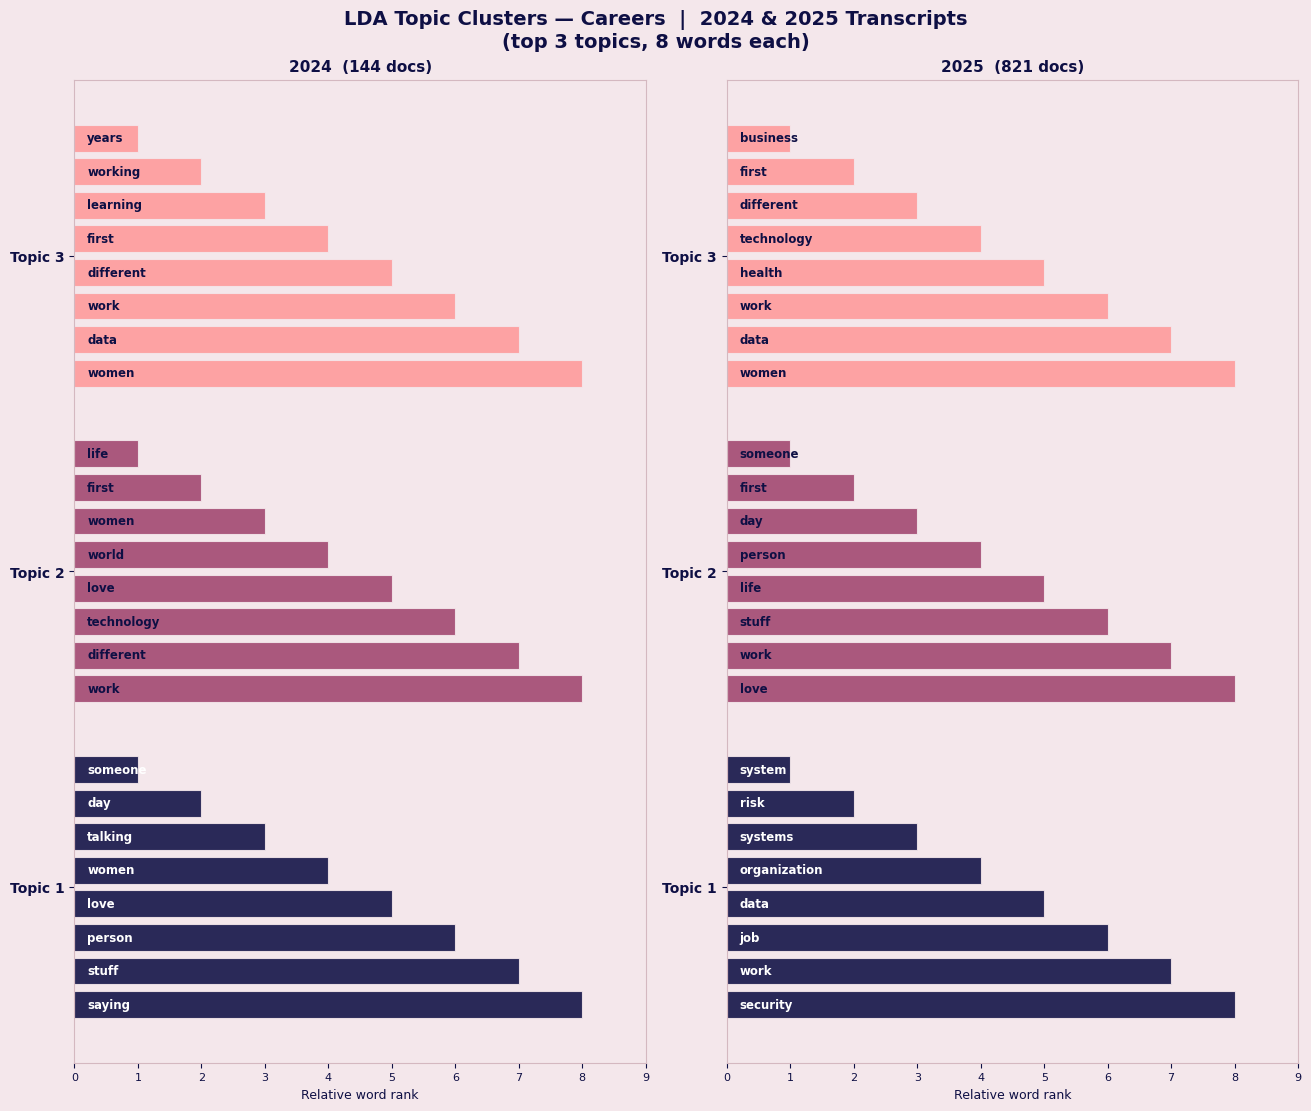

In [ ]:
_BG_COLOR      = "#f4e7eb"
_TARGET_YEARS  = [2024, 2025]
_TOPIC_PALETTE = ["#0e0f44", "#a0446e", "#ff9999"]  # navy → rose → pink

# ── Slice careers transcripts for 2024 & 2025 only ───────────────────────────
_mask_careers = df_t["categories"].astype(str).str.contains("careers", na=False)
_df_careers   = df_t.loc[_mask_careers & df_t["year"].isin(_TARGET_YEARS), ["year", "text"]]

docs_95 = {
    yr: _df_careers.loc[_df_careers["year"] == yr, "text"].astype(str).tolist()
    for yr in _TARGET_YEARS
}

# ── Layout: one column per year, single row (transcripts only) ────────────────
fig, axes = plt.subplots(
    1, len(_TARGET_YEARS),
    figsize=(6.5 * len(_TARGET_YEARS), 11),
    constrained_layout=True,
)
fig.patch.set_facecolor(_BG_COLOR)
fig.suptitle(
    f"LDA Topic Clusters — Careers  |  2024 & 2025 Transcripts\n"
    f"(top {_N_TOPICS} topics, {_N_TOP_WORDS} words each)",
    fontsize=14, fontweight="bold", color="#0e0f44",
)

for col, year in enumerate(_TARGET_YEARS):
    ax   = axes[col]
    ax.set_facecolor(_BG_COLOR)
    docs = docs_95.get(year, [])
    topics = _run_lda_year(docs)

    ax.set_title(f"{year}  ({len(docs)} docs)",
                 fontsize=11, fontweight="bold", color="#0e0f44")

    if topics is None:
        ax.text(0.5, 0.5, "Not enough data",
                ha="center", va="center",
                transform=ax.transAxes, fontsize=10, color="#0e0f44")
        ax.axis("off")
        continue

    y_base  = 0
    y_ticks = []
    y_lbls  = []
    gap     = 1.4

    for t_idx, words in enumerate(topics):
        color  = _TOPIC_PALETTE[t_idx % len(_TOPIC_PALETTE)]
        y_pos  = [y_base + i for i in range(len(words))]
        widths = [len(words) - i for i in range(len(words))]
        bars   = ax.barh(y_pos, widths, color=color, alpha=0.88,
                         edgecolor=_BG_COLOR, linewidth=0.8)
        for y, word in zip(y_pos, words):
            ax.text(0.2, y, word, va="center", fontsize=8.5,
                    color="white" if t_idx == 0 else "#0e0f44",
                    fontweight="bold")
        mid = y_base + len(words) / 2 - 0.5
        y_ticks.append(mid)
        y_lbls.append(f"Topic {t_idx + 1}")
        y_base += len(words) + gap

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_lbls, fontsize=10, fontweight="bold", color="#0e0f44")
    ax.set_xlabel("Relative word rank", fontsize=9, color="#0e0f44")
    ax.tick_params(axis="x", labelsize=8, colors="#0e0f44")
    ax.tick_params(axis="y", colors="#0e0f44")
    ax.set_xlim(0, _N_TOP_WORDS + 1)
    for spine in ax.spines.values():
        spine.set_edgecolor("#d4b8c0")

plt.show()
